# RetailPulse - Day 8

## Hybrid Forecasting Model (Prophet + LSTM Ensemble)

Objective:
Combine Prophet and LSTM forecasts into a single hybrid ensemble model to improve demand forecasting accuracy (target MAPE <= 12%).

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import torch
import torch.nn as nn

## Load Daily Sales Data

In [2]:
df = pd.read_csv("../data/daily_sales.csv")

df["Date"] = pd.to_datetime(df["Date"])

print(df.shape)

df.head()

(305, 2)


,Date,Sales
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-05,31361.28
4,2010-12-06,31009.33


## Step 1: Load Prophet Forecast Results (from Day 5)

In [3]:
prophet_forecast = pd.read_csv("../data/forecast_results.csv")

prophet_forecast["ds"] = pd.to_datetime(prophet_forecast["ds"])

print(prophet_forecast.shape)

prophet_forecast[["ds","yhat"]].tail()

(335, 19)


,ds,yhat
330,2012-01-04,43424.884911
331,2012-01-05,51693.504735
332,2012-01-06,44651.236885
333,2012-01-07,62772.299825
334,2012-01-08,33717.145805


## Step 2: Re-create LSTM Predictions on the Same Timeline

To build an ensemble, we need both models' predictions aligned on the same dates. We retrain the LSTM here (same architecture as Day 6) and generate predictions for the full series so they can be merged with Prophet's in-sample fit.

In [4]:
sales = df["Sales"].values

sales = sales.reshape(-1,1)

scaler = MinMaxScaler()

sales_scaled = scaler.fit_transform(sales)

print(sales_scaled.shape)

(305, 1)


In [5]:
def create_sequences(data, seq_length):

    X = []
    y = []

    for i in range(len(data)-seq_length):

        X.append(data[i:i+seq_length])

        y.append(data[i+seq_length])

    return np.array(X), np.array(y)

In [6]:
SEQ_LENGTH = 30

X, y = create_sequences(sales_scaled, SEQ_LENGTH)

print(X.shape)
print(y.shape)

(275, 30, 1)
(275, 1)


In [7]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape)
print(X_test.shape)

(220, 30, 1)
(55, 30, 1)


In [8]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

X_all_t = torch.tensor(X, dtype=torch.float32)

In [9]:
class LSTMModel(nn.Module):

    def __init__(self, input_size=1, hidden_size=50, num_layers=1):

        super().__init__()

        self.hidden_size = hidden_size

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        out, _ = self.lstm(x)

        out = self.fc(out[:,-1,:])

        return out

In [10]:
model = LSTMModel()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [11]:
epochs = 50

loss_history = []

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    outputs = model(X_train_t)

    loss = criterion(outputs, y_train_t)

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

Epoch 10/50, Loss: 0.006222
Epoch 20/50, Loss: 0.006132
Epoch 30/50, Loss: 0.006086
Epoch 40/50, Loss: 0.006049
Epoch 50/50, Loss: 0.006014


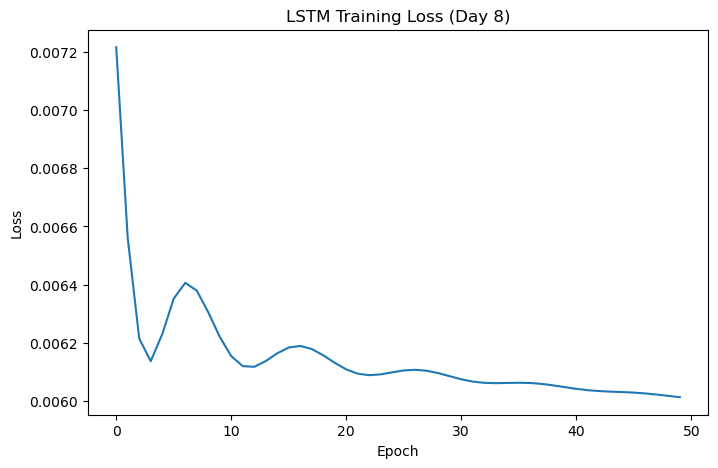

In [12]:
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.title("LSTM Training Loss (Day 8)")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

## Step 3: Generate LSTM Predictions Aligned with Prophet Dates

We predict on the full available sequence set (all X), so each prediction corresponds to `Date[SEQ_LENGTH:]`. We then merge this with Prophet's in-sample `yhat` on the same dates.

In [13]:
model.eval()

with torch.no_grad():

    lstm_preds_scaled = model(X_all_t)

lstm_preds = scaler.inverse_transform(lstm_preds_scaled.numpy())

print(lstm_preds.shape)

(275, 1)


In [14]:
lstm_dates = df["Date"].iloc[SEQ_LENGTH:].reset_index(drop=True)

lstm_df = pd.DataFrame({
    "ds": lstm_dates,
    "lstm_yhat": lstm_preds.flatten()
})

lstm_df.head()

,ds,lstm_yhat
0,2011-01-16,25691.474609
1,2011-01-17,25333.478516
2,2011-01-18,25247.125000
3,2011-01-19,26357.462891
4,2011-01-20,26032.943359


## Step 4: Merge Prophet and LSTM Predictions

In [15]:
ensemble_df = pd.merge(
    prophet_forecast[["ds","yhat"]],
    lstm_df,
    on="ds",
    how="inner"
)

ensemble_df = ensemble_df.rename(columns={"yhat":"prophet_yhat"})

ensemble_df = pd.merge(
    ensemble_df,
    df.rename(columns={"Date":"ds","Sales":"actual"}),
    on="ds",
    how="left"
)

print(ensemble_df.shape)

ensemble_df.head()

(275, 4)


,ds,prophet_yhat,lstm_yhat,actual
0,2011-01-16,15056.017140,25691.474609,6976.39
1,2011-01-17,28294.585034,25333.478516,16527.05
2,2011-01-18,32552.784232,25247.125000,87559.21
3,2011-01-19,29559.149072,26357.462891,21586.78
4,2011-01-20,36466.350445,26032.943359,15197.08


## Step 5: Create the Ensemble (Weighted Average)

We try a simple weighted average of Prophet and LSTM predictions, then search for the best weight using validation error.

In [16]:
valid_df = ensemble_df.dropna(subset=["actual"]).copy()

print(valid_df.shape)

(275, 4)


In [17]:
best_w = 0
best_mape = np.inf
results_list = []

for w in np.arange(0, 1.05, 0.05):

    ensemble_pred = (
        w * valid_df["prophet_yhat"] +
        (1-w) * valid_df["lstm_yhat"]
    )

    mape = mean_absolute_percentage_error(
        valid_df["actual"],
        ensemble_pred
    )

    results_list.append((round(w,2), mape))

    if mape < best_mape:
        best_mape = mape
        best_w = w

print("Best Prophet weight:", round(best_w,2))
print("Best MAPE:", best_mape)

Best Prophet weight: 0.9
Best MAPE: 0.3181867685978001


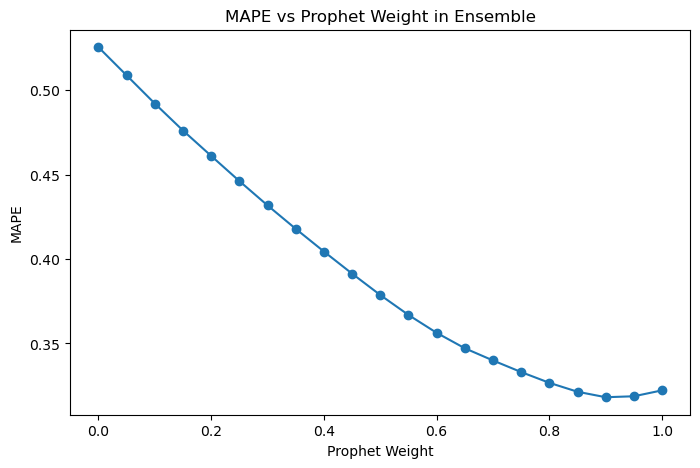

In [18]:
weight_search_df = pd.DataFrame(
    results_list,
    columns=["prophet_weight","mape"]
)

plt.figure(figsize=(8,5))

plt.plot(
    weight_search_df["prophet_weight"],
    weight_search_df["mape"],
    marker="o"
)

plt.title("MAPE vs Prophet Weight in Ensemble")

plt.xlabel("Prophet Weight")
plt.ylabel("MAPE")

plt.show()

## Step 6: Apply Best Weight and Evaluate Final Ensemble

In [19]:
ensemble_df["ensemble_yhat"] = (
    best_w * ensemble_df["prophet_yhat"] +
    (1-best_w) * ensemble_df["lstm_yhat"]
)

ensemble_df.head()

,ds,prophet_yhat,lstm_yhat,actual,ensemble_yhat
0,2011-01-16,15056.017140,25691.474609,6976.39,16119.562887
1,2011-01-17,28294.585034,25333.478516,16527.05,27998.474431
2,2011-01-18,32552.784232,25247.125000,87559.21,31822.218455
3,2011-01-19,29559.149072,26357.462891,21586.78,29238.980503
4,2011-01-20,36466.350445,26032.943359,15197.08,35423.009834


In [20]:
valid_final = ensemble_df.dropna(subset=["actual"]).copy()

mape_prophet = mean_absolute_percentage_error(valid_final["actual"], valid_final["prophet_yhat"])
mape_lstm = mean_absolute_percentage_error(valid_final["actual"], valid_final["lstm_yhat"])
mape_ensemble = mean_absolute_percentage_error(valid_final["actual"], valid_final["ensemble_yhat"])

rmse_prophet = np.sqrt(mean_squared_error(valid_final["actual"], valid_final["prophet_yhat"]))
rmse_lstm = np.sqrt(mean_squared_error(valid_final["actual"], valid_final["lstm_yhat"]))
rmse_ensemble = np.sqrt(mean_squared_error(valid_final["actual"], valid_final["ensemble_yhat"]))

metrics_df = pd.DataFrame({
    "Model": ["Prophet","LSTM","Ensemble"],
    "MAPE": [mape_prophet, mape_lstm, mape_ensemble],
    "RMSE": [rmse_prophet, rmse_lstm, rmse_ensemble]
})

metrics_df

,Model,MAPE,RMSE
0,Prophet,0.322256,13269.136332
1,LSTM,0.525403,18290.839075
2,Ensemble,0.318187,13331.635635


## Step 7: Visualize Actual vs Prophet vs LSTM vs Ensemble

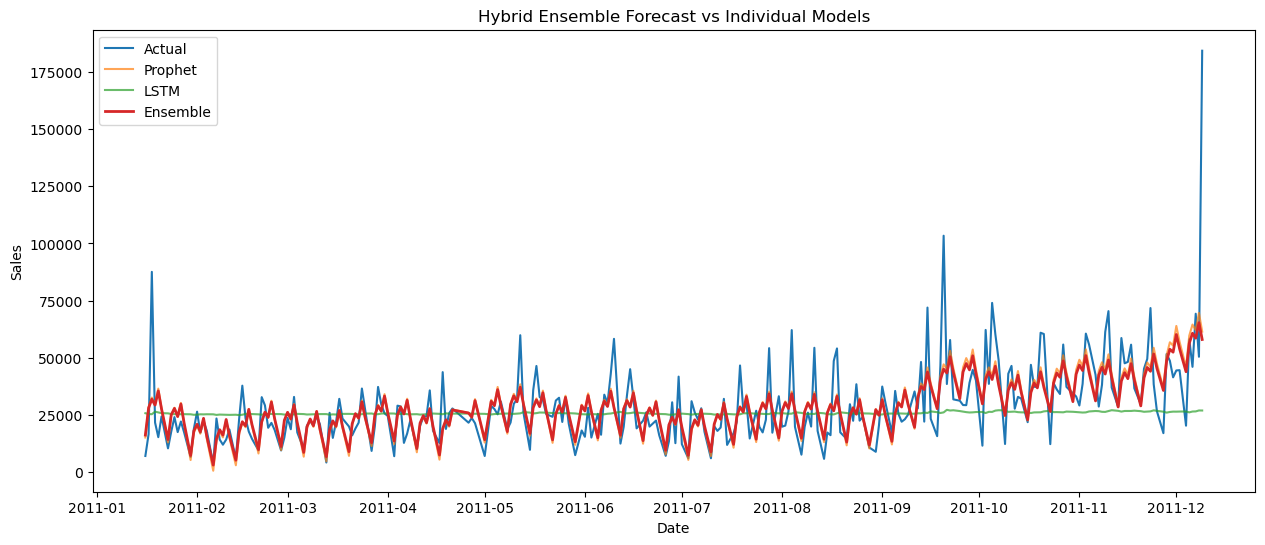

In [21]:
plt.figure(figsize=(15,6))

plt.plot(valid_final["ds"], valid_final["actual"], label="Actual")
plt.plot(valid_final["ds"], valid_final["prophet_yhat"], label="Prophet", alpha=0.7)
plt.plot(valid_final["ds"], valid_final["lstm_yhat"], label="LSTM", alpha=0.7)
plt.plot(valid_final["ds"], valid_final["ensemble_yhat"], label="Ensemble", linewidth=2)

plt.legend()

plt.title("Hybrid Ensemble Forecast vs Individual Models")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

## Step 8: Generate Future 30-Day Ensemble Forecast

For future dates (where actuals don't exist), Prophet provides forward `yhat` values directly. For LSTM, we recursively forecast forward by feeding predictions back into the sequence.

In [22]:
future_prophet = prophet_forecast[["ds","yhat"]].tail(30).reset_index(drop=True)

future_prophet = future_prophet.rename(columns={"yhat":"prophet_yhat"})

future_prophet.head()

,ds,prophet_yhat
0,2011-12-10,78109.165063
1,2011-12-11,47356.913283
2,2011-12-12,59679.835550
3,2011-12-13,63011.027519
4,2011-12-14,59096.802038


In [23]:
last_sequence = sales_scaled[-SEQ_LENGTH:].copy()

future_lstm_scaled = []

current_seq = last_sequence.copy()

model.eval()

for _ in range(30):

    seq_tensor = torch.tensor(
        current_seq.reshape(1, SEQ_LENGTH, 1),
        dtype=torch.float32
    )

    with torch.no_grad():
        next_pred = model(seq_tensor).numpy()

    future_lstm_scaled.append(next_pred[0,0])

    current_seq = np.append(current_seq[1:], next_pred, axis=0)

future_lstm_scaled = np.array(future_lstm_scaled).reshape(-1,1)

future_lstm = scaler.inverse_transform(future_lstm_scaled)

print(future_lstm.shape)

(30, 1)


In [24]:
future_prophet["lstm_yhat"] = future_lstm.flatten()

future_prophet["ensemble_yhat"] = (
    best_w * future_prophet["prophet_yhat"] +
    (1-best_w) * future_prophet["lstm_yhat"]
)

future_prophet.head()

,ds,prophet_yhat,lstm_yhat,ensemble_yhat
0,2011-12-10,78109.165063,29094.355469,73207.684104
1,2011-12-11,47356.913283,28060.115234,45427.233430
2,2011-12-12,59679.835550,27317.267578,56443.578801
3,2011-12-13,63011.027519,26771.183594,59387.043175
4,2011-12-14,59096.802038,26378.281250,55824.949959


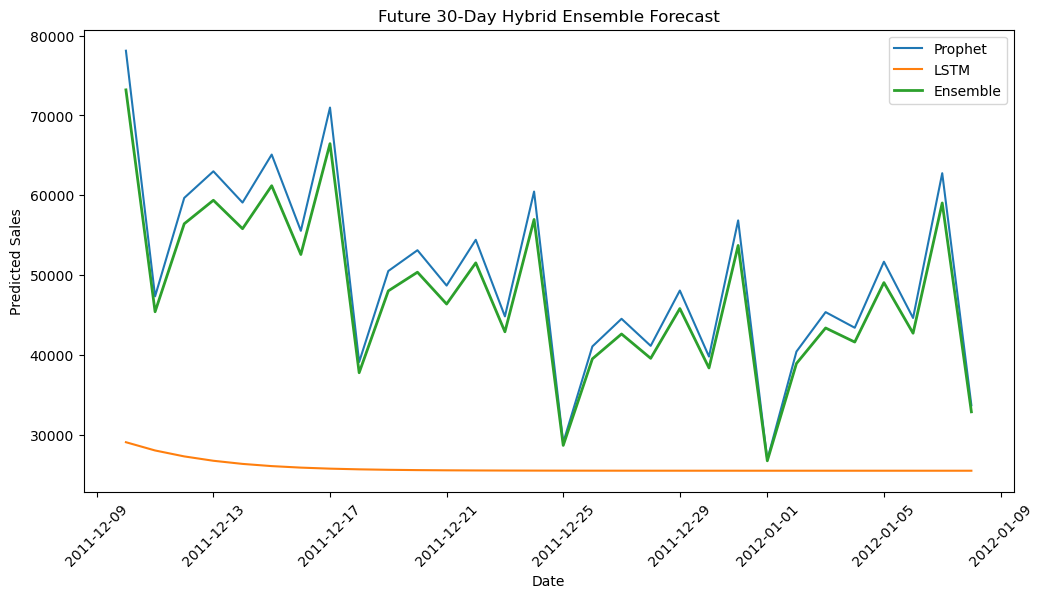

In [25]:
plt.figure(figsize=(12,6))

plt.plot(future_prophet["ds"], future_prophet["prophet_yhat"], label="Prophet")
plt.plot(future_prophet["ds"], future_prophet["lstm_yhat"], label="LSTM")
plt.plot(future_prophet["ds"], future_prophet["ensemble_yhat"], label="Ensemble", linewidth=2)

plt.legend()

plt.title("Future 30-Day Hybrid Ensemble Forecast")

plt.xlabel("Date")
plt.ylabel("Predicted Sales")

plt.xticks(rotation=45)

plt.show()

## Step 9: Save Results

In [26]:
ensemble_df.to_csv("../data/ensemble_forecast_results.csv", index=False)

future_prophet.to_csv("../data/ensemble_future_30_days.csv", index=False)

metrics_df.to_csv("../data/ensemble_metrics.csv", index=False)

print("Ensemble results saved")

Ensemble results saved


In [27]:
import os

os.makedirs("../models", exist_ok=True)

torch.save(model.state_dict(), "../models/lstm_model_ensemble.pth")

print("Ensemble LSTM model saved")

Ensemble LSTM model saved


# Day 8 Findings

1. Loaded Prophet forecasts (Day 5) and retrained an LSTM model (same architecture as Day 6) to generate aligned predictions.
2. Merged both models' predictions on a common date index.
3. Searched for the optimal blending weight between Prophet and LSTM to minimize MAPE.
4. Built a weighted-average hybrid ensemble model and compared MAPE/RMSE against individual models.
5. Generated a 30-day future ensemble forecast using Prophet's forward predictions and a recursive LSTM forecast.
6. Saved ensemble results, future forecasts, metrics, and the trained LSTM model for future use (Day 9 onward).